# Lab 4 - part2
### Edge Detection

https://github.com/scikit-image/scikit-image/blob/master/skimage/filters/edges.py

http://scikit-image.org/docs/0.11.x/auto_examples/plot_edge_filter.html

http://scikit-image.org/docs/dev/auto_examples/edges/plot_canny.html



In [39]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
'''
1. Built-in Sobel, Prewill, Roberts, Canny
2. Custom Sobel (V-H-Both)
3. Custom LoG
'''

'\n1. Built-in Sobel, Prewill, Roberts, Canny\n2. Custom Sobel (V-H-Both)\n3. Custom LoG\n'

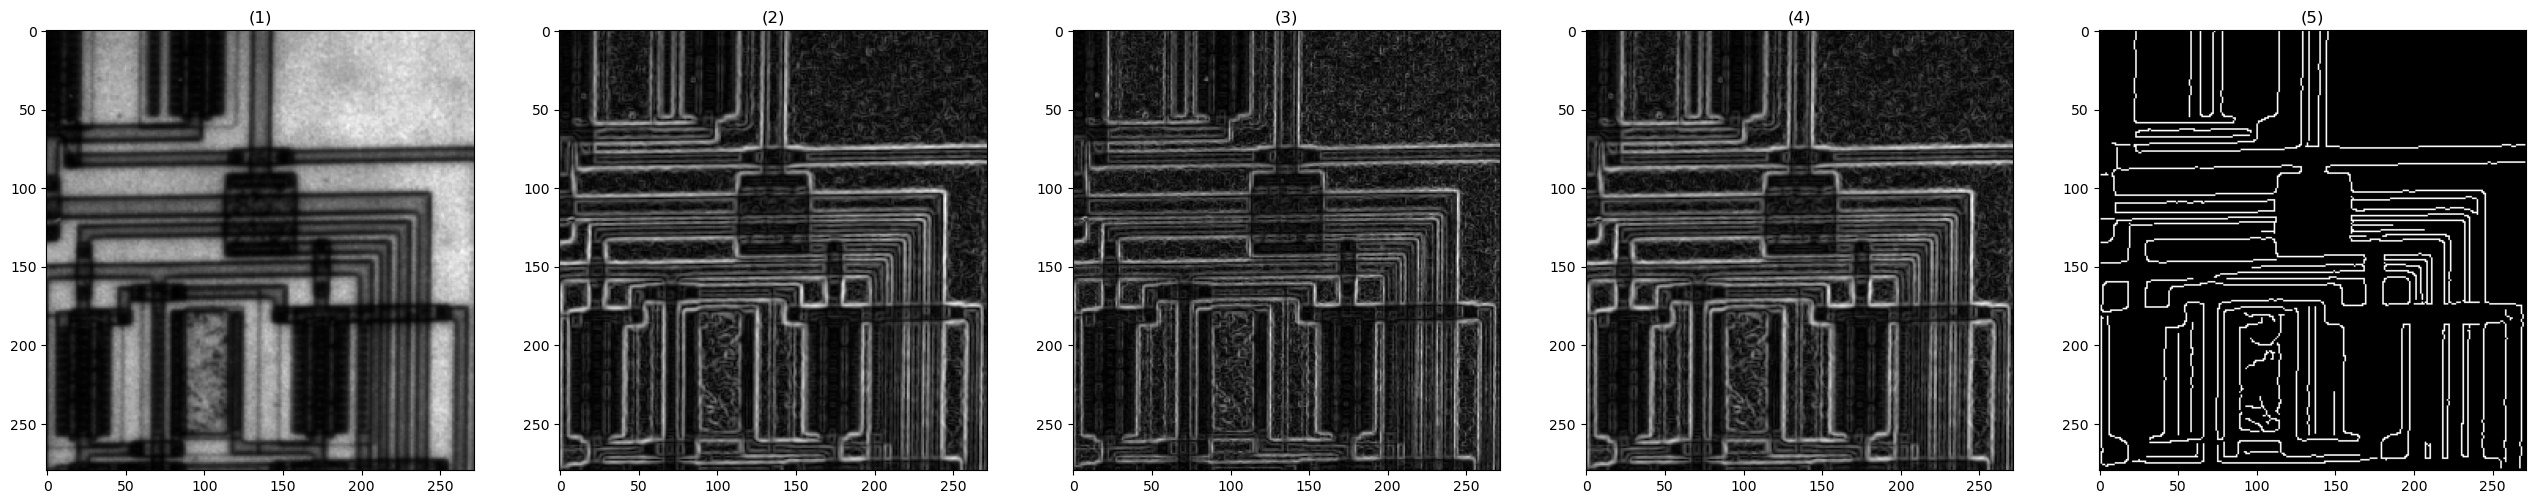

In [ ]:
# 1. Built-in Sobel, Prewill, Roberts, Canny

img = io.imread('circuit.tif')

imgPrewitt = prewitt(img)
imgRoberts = roberts(img)
imgSobel = sobel(img)
imgCanny = canny(img, sigma=1.4, low_threshold=30, high_threshold=70)

show_images([img, imgPrewitt, imgRoberts, imgSobel, imgCanny])

#For prewitt, roberts and sobel algorithms:
#Roberts has high sensitivity to noise
#Prewitt can calculate the difference in 8 possible directions
#Sobel works by summing the absolute of the x component of changing and y component of changing

#For canny algorithm :
#Large sigma detects large scale edges but small sigma detects fine features
#Low threshold and high threshold are used for detecting edges as if any value in the deravative matrix of the image is lower than
# the low thershold it is not considered as an edge and it it is higher than the high threshold it is considered as a strong edge and
# if it is between low threshold and high threshold it is considered as weak edge and it is considered edge if there is an edge nearby

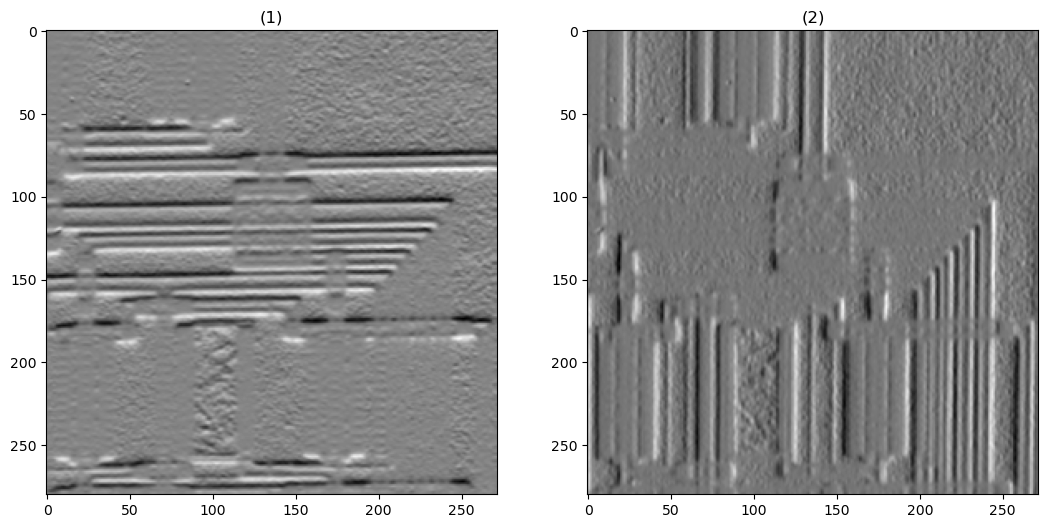

In [42]:
imgSobelH = sobel_h(img)
imgSobelV = sobel_v(img)

show_images([imgSobelH, imgSobelV])

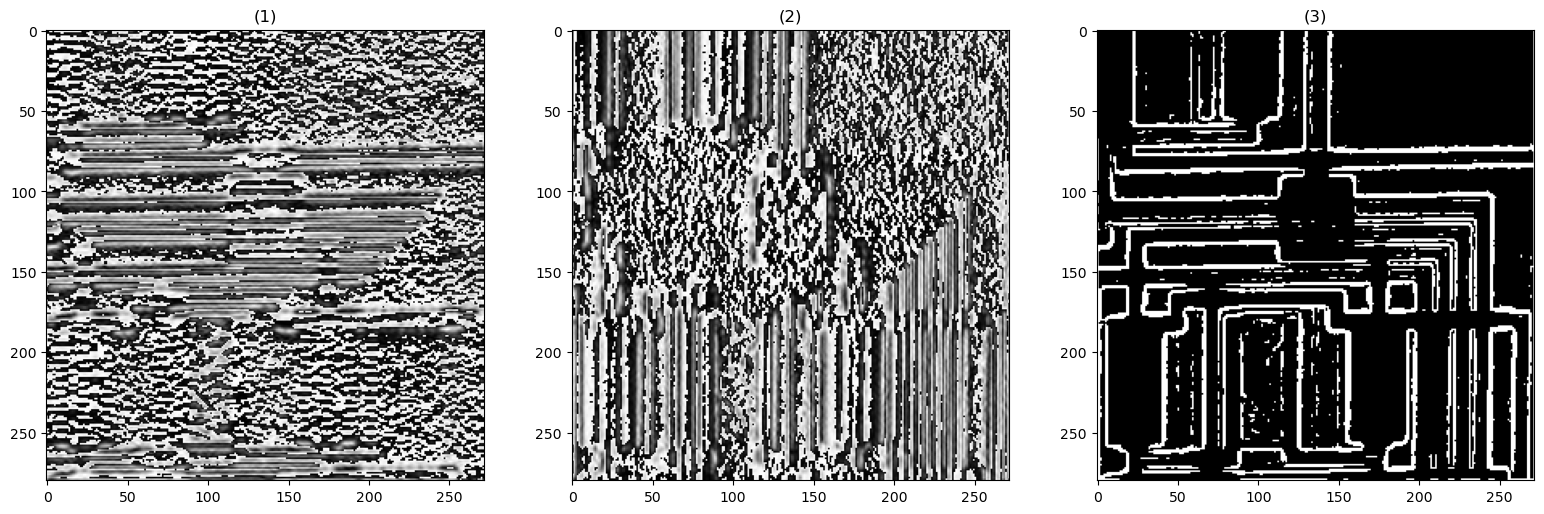

In [43]:
# 2. Custom Sobel (V-H-Both)

def customSobel(image, threshold=115):
    height, width = image.shape
    hy = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    hx = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    output_imageX = np.copy(image)
    output_imageY = np.copy(image)
    output_image = np.copy(image)

    for i in range(height):
        for j in range(width):
            convolutionSumX = 0
            convolutionSumY = 0
            for m in range(i - 1, i + 2):
                for n in range(j - 1, j + 2):
                    if(m < 0 or m >= height or n < 0 or n >= width):
                        continue
                    convolutionSumX += hx[m - (i - 1)][n - (j - 1)] * image[m][n]
                    convolutionSumY += hy[m - (i - 1)][n - (j - 1)] * image[m][n]
            output_imageX[i][j] = convolutionSumX
            output_imageY[i][j] = convolutionSumY
            convolutionSum = math.sqrt(convolutionSumX**2 + convolutionSumY**2)
            if convolutionSum >= threshold:
                output_image[i][j] = 255
            else:
                output_image[i][j] = 0

    return output_imageX, output_imageY, output_image

imgCustomSobelX, imageCustomSobelY, imageCustomSobel = customSobel(img)
show_images([imgCustomSobelX, imageCustomSobelY, imageCustomSobel])



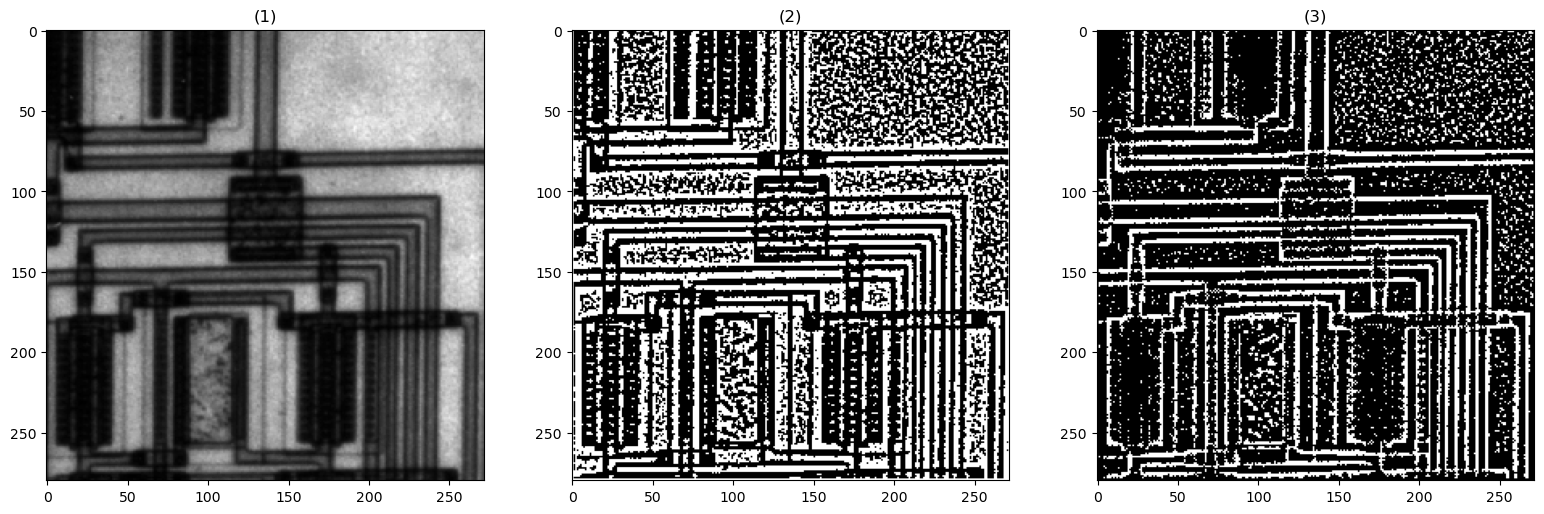

In [69]:
# 3. Custom LoG
thres= 20

def customLoG(image, threshold=thres):
    height, width = image.shape
    gaussianFilteredImage = gaussian(image, sigma=0.7)
    gaussianFilteredImage = gaussianFilteredImage * 255
    gaussianFilteredImage = gaussianFilteredImage.astype(np.uint8)  
    f1 = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
    f2 = np.array([[0,1,0],[1,-4,1],[0,1,0]])

    outputImageF1 = np.copy(image)
    outputImageF2 = np.copy(image)

    for i in range(height):
        for j in range(width):
            convolutionSumF1 = 0
            convolutionSumF2 = 0
            for m in range(i - 1, i + 2):
                for n in range(j - 1, j + 2):
                    if(m < 0 or m >= height or n < 0 or n >= width):
                        continue
                    convolutionSumF1 += f1[m - (i - 1)][n - (j - 1)] * gaussianFilteredImage[m][n]
                    convolutionSumF2 += f2[m - (i - 1)][n - (j - 1)] * gaussianFilteredImage[m][n]
            outputImageF1[i][j] = convolutionSumF1
            outputImageF1[i][j] = convolutionSumF2

            if convolutionSumF1 >= threshold:
                outputImageF1[i][j] = 255
            else:
                outputImageF1[i][j] = 0

            if convolutionSumF2 >= threshold:
                outputImageF2[i][j] = 255
            else:
                outputImageF2[i][j] = 0

    return outputImageF1, outputImageF2

imgLoG_F1, imgLog_F2 = customLoG(img, 5)
show_images([img, imgLoG_F1, imgLog_F2]) 

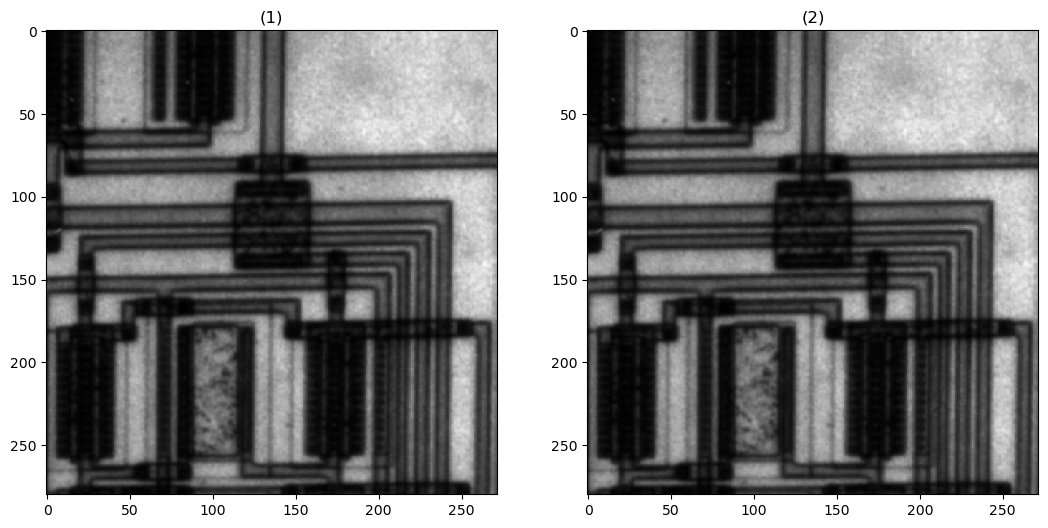

In [72]:
'''
Optional
1-Make edge detection
2-Multiply by factor < 1
3-Subtract (Orginal Image) - (Edge Detection Image)
'''

imgCannyTest = canny(img, sigma=1.3, low_threshold=30, high_threshold=70)
imgCannyTest = imgCannyTest * 0.8
resultImgTest = img - imgCannyTest

show_images([img, resultImgTest])